import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set()

In [4]:
df = sns.load_dataset("titanic")

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.shape

(891, 15)

In [10]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [14]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [18]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

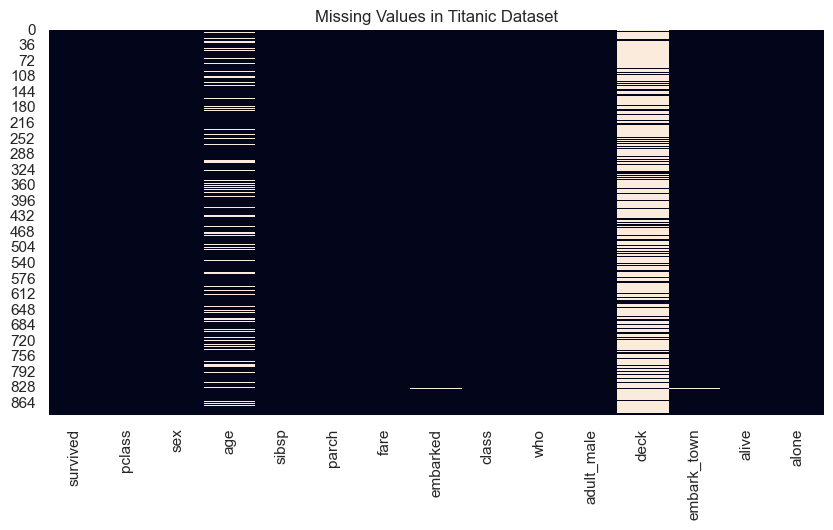

In [20]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Titanic Dataset")
plt.show()

In [22]:
df.duplicated().sum()

107

In [24]:
df = df.drop_duplicates()

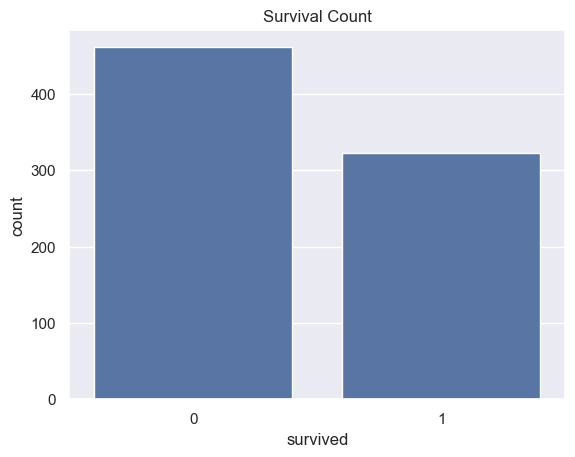

In [26]:
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

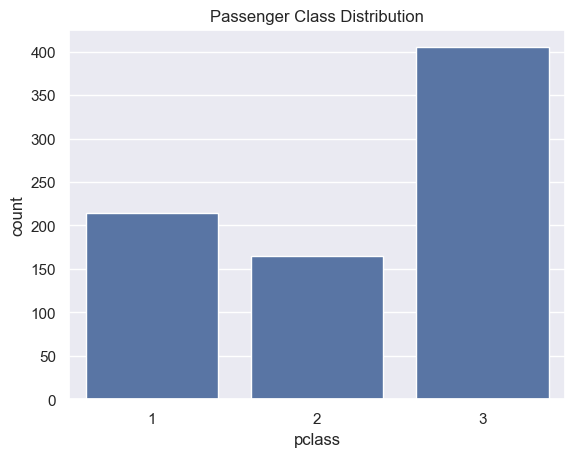

In [28]:
sns.countplot(x='pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

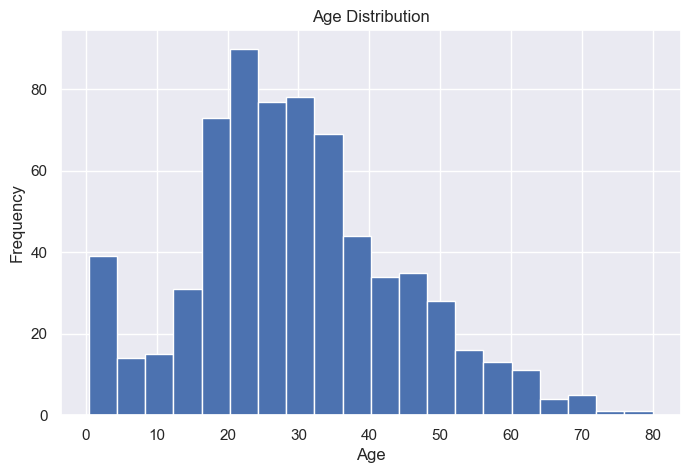

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df['age'].dropna(), bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

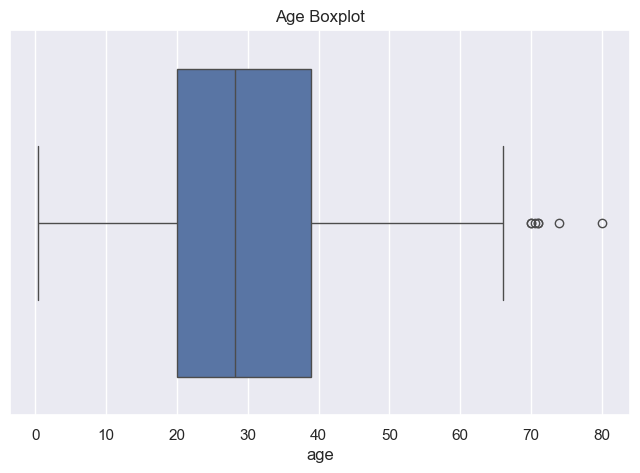

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['age'])
plt.title("Age Boxplot")
plt.show()

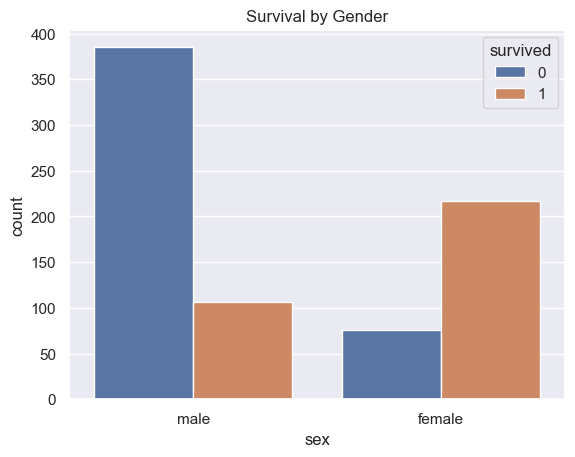

In [34]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

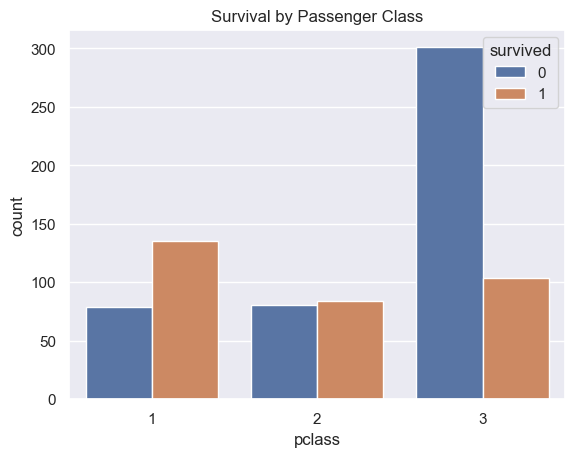

In [36]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

In [40]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.332658,-0.086548,-0.036589,0.070307,0.246769
pclass,-0.332658,1.000000,-0.369361,0.088014,0.040296,-0.549216
age,-0.086548,-0.369361,1.000000,-0.315116,-0.195036,0.092707
sibsp,-0.036589,0.088014,-0.315116,1.000000,0.381433,0.135147
parch,0.070307,0.040296,-0.195036,0.381433,1.000000,0.191942
fare,0.246769,-0.549216,0.092707,0.135147,0.191942,1.000000


<Figure size 1000x700 with 0 Axes>

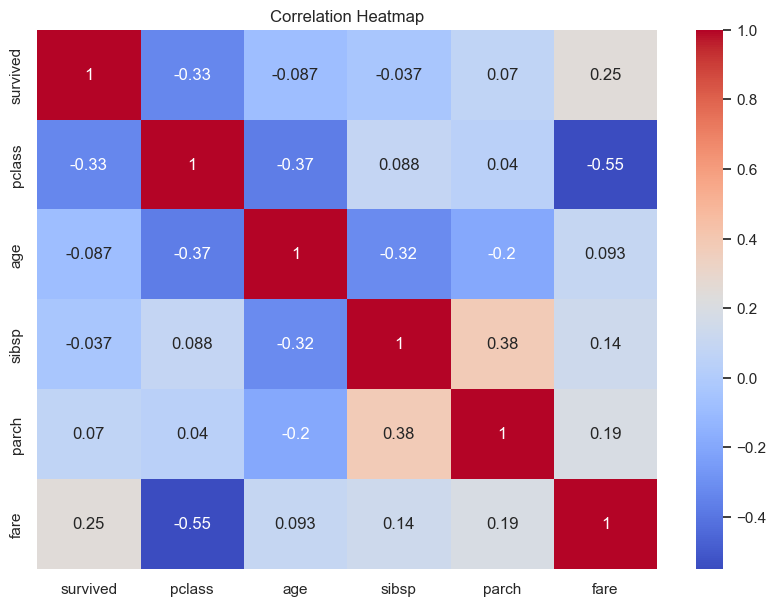

In [42]:
plt.figure(figsize=(10,7))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships
between numerical variables. It helps identify variables that have stronger
positive or negative relationships.

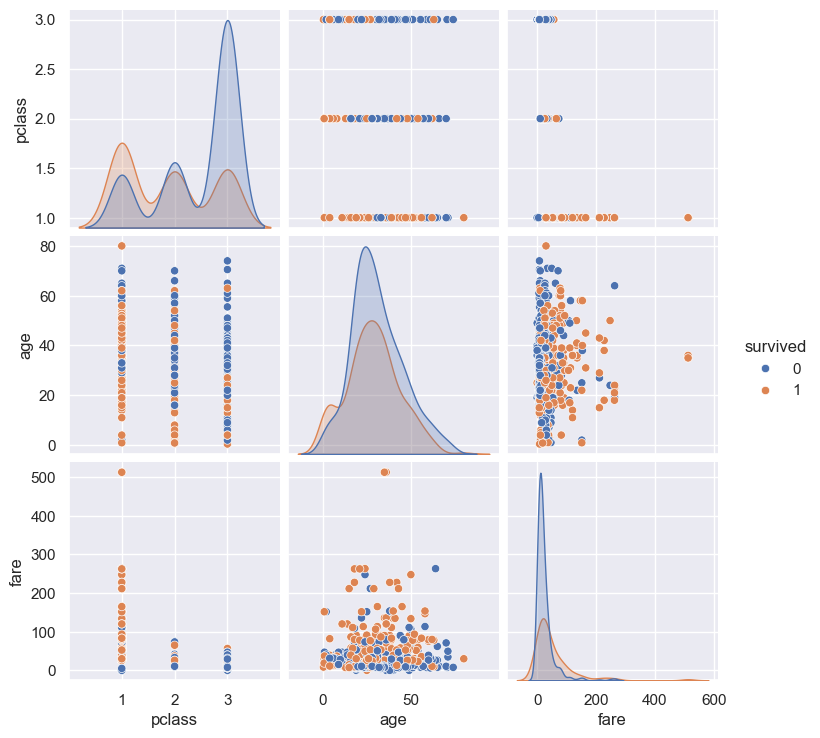

In [44]:
sns.pairplot(
    df[['survived', 'pclass', 'age', 'fare']].dropna(),
    hue='survived'
)
plt.show()

In [46]:
df['sex'].value_counts()

sex
male      491
female    293
Name: count, dtype: int64

In [48]:
df['pclass'].value_counts()

pclass
3    405
1    214
2    165
Name: count, dtype: int64

In [50]:
df['survived'].value_counts()

survived
0    461
1    323
Name: count, dtype: int64

In [52]:
df['survived'].value_counts(normalize=True) * 100

survived
0    58.80102
1    41.19898
Name: proportion, dtype: float64

In [54]:
pd.crosstab(df['sex'], df['survived'], normalize='index') * 100

survived,0,1
sex,,
female,25.938567,74.061433
male,78.411405,21.588595


EDA Summary:
Exploratory Data Analysis was performed on the Titanic dataset using Pandas, Matplotlib and Seaborn. The dataset was examined using descriptive statistics, missing-value analysis, histograms, boxplots, scatterplots, pairplots and correlation heatmaps. The analysis revealed important relationships between survival, gender and passenger class. The EDA also helped identify missing values, distributions, trends and possible outliers.

# TASK 5: EXPLORATORY DATA ANALYSIS (EDA)

## Titanic Dataset

### Objective
To perform Exploratory Data Analysis on the Titanic dataset and identify
important patterns, trends, relationships, and anomalies.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Dataset Description

The Titanic dataset contains information about passengers who travelled
on the Titanic.

The analysis focuses on variables such as:
- Passenger class
- Sex
- Age
- Fare
- Survival status

The objective is to understand the factors associated with passenger survival.

## 2. Data Understanding

The dataset was examined using shape, columns, info(), describe(), and
value_counts() to understand its structure and characteristics.

In [ ]:
4. Missing Value Analysis
Missing values were identified in some columns of the Titanic dataset.Numerical missing values such as age were handled using the median,while categorical 
missing values such as embarked were handled using the mode.
The deck column was removed because it contains a large number of missing values and is not required for the main analysis.

5. Univariate Analysis
   - Survival Count
   - Passenger Class
   - Age Histogram
   - Age Boxplot
# 5. Univariate Analysis

Univariate analysis involves analyzing one variable at a time.
In this analysis, survival status, passenger class, and age
distribution are examined using countplots, histograms and boxplots.

5.1 The graph shows the number of passengers who survived and did not survive. 
The number of passengers who did not survive is higher than the number who survived.
    
5.2 The graph shows the distribution of passengers among the three passenger classes. 
Third-class passengers form a large proportion of the dataset.

5.3 The histogram shows the distribution of passenger ages. 
Most passengers are concentrated in the young and middle-age groups, while fewer passengers are present at very high ages.

5.4 The boxplot shows the median, spread, and possible outliers in passenger age.
It helps identify passengers whose ages are unusually high or low compared with the rest of the dataset.

6. Bivariate Analysis
   - Survival vs Gender
   - Survival vs Passenger Class
   - Age vs Fare Scatterplot
# 6. Bivariate Analysis

Bivariate analysis is used to examine the relationship between two variables.
In this analysis, survival is compared with gender and passenger class.
The relationship between age and fare is also examined using a scatterplot.
### Observation

The graph shows a relationship between gender and survival.
Female passengers had a higher survival rate compared with male passengers.
### Observation

The graph shows that passenger class is related to survival.
Passengers in higher classes generally had better survival outcomes,
while third-class passengers had a lower survival proportion.
### Observation

The scatterplot shows the relationship between passenger age and fare.
Fare values vary considerably among passengers of different ages.
The survival status also shows variation across the plotted observations.

7. Multivariate Analysis
   - Correlation Heatmap
   - Pairplot
# 7. Multivariate Analysis

## 7.1 Correlation Heatmap

### Observation
The correlation heatmap shows the strength and direction of relationships
between numerical variables.

## 7.2 Pairplot

### Observation
The pairplot shows relationships and distributions among multiple
numerical variables and helps identify patterns in the dataset.

# Key Findings

1. Gender is an important factor associated with survival.
2. Passenger class shows a relationship with survival.
3. The age distribution contains passengers from different age groups.
4. Fare values vary considerably among passengers.
5. Missing values were identified in some columns.
6. Correlation analysis helped identify relationships between numerical variables.
7. Visualizations helped identify patterns and trends in the dataset.

# Conclusion

Exploratory Data Analysis was successfully performed on the Titanic dataset
using Python, Pandas, Matplotlib and Seaborn.

Different statistical methods and visualizations were used to understand
the dataset. Histograms, boxplots, scatterplots, pairplots and correlation
heatmaps helped identify patterns, relationships and possible anomalies.

The analysis shows that factors such as gender and passenger class are
important in understanding survival outcomes.